# 4. Retrieve methane with a column-wise matched filter

The main result uses the v2 two-pass column-wise matched filter at 2.3 micrometres. It removes likely plume pixels before estimating the background covariance and adjusts for pixel brightness. The 1.65 micrometre result is kept as a secondary spectral-window check.

## Run the v2 retrieval at 2.3 micrometres

The implementation is in `scripts/matched_filter_v2.py`. It reads the basic radiance cubes, builds the methane target from the local HITRAN cache, applies the two-pass filter, and compares the result with Planet's methane quicklook.

In [ ]:
from pathlib import Path
import runpy
from IPython.display import Image, display

PACKAGE_ROOT = Path.cwd().resolve()
while not (PACKAGE_ROOT / "scripts").is_dir() and PACKAGE_ROOT != PACKAGE_ROOT.parent:
    PACKAGE_ROOT = PACKAGE_ROOT.parent

FIG_DIR = PACKAGE_ROOT / "figures"
runpy.run_path(str(PACKAGE_ROOT / "scripts" / "matched_filter_v2.py"), run_name="__main__")

## Detection map

The full strips are shown above the closer views of the strongest plume locations. Provider plume centres are used only as reference markers.

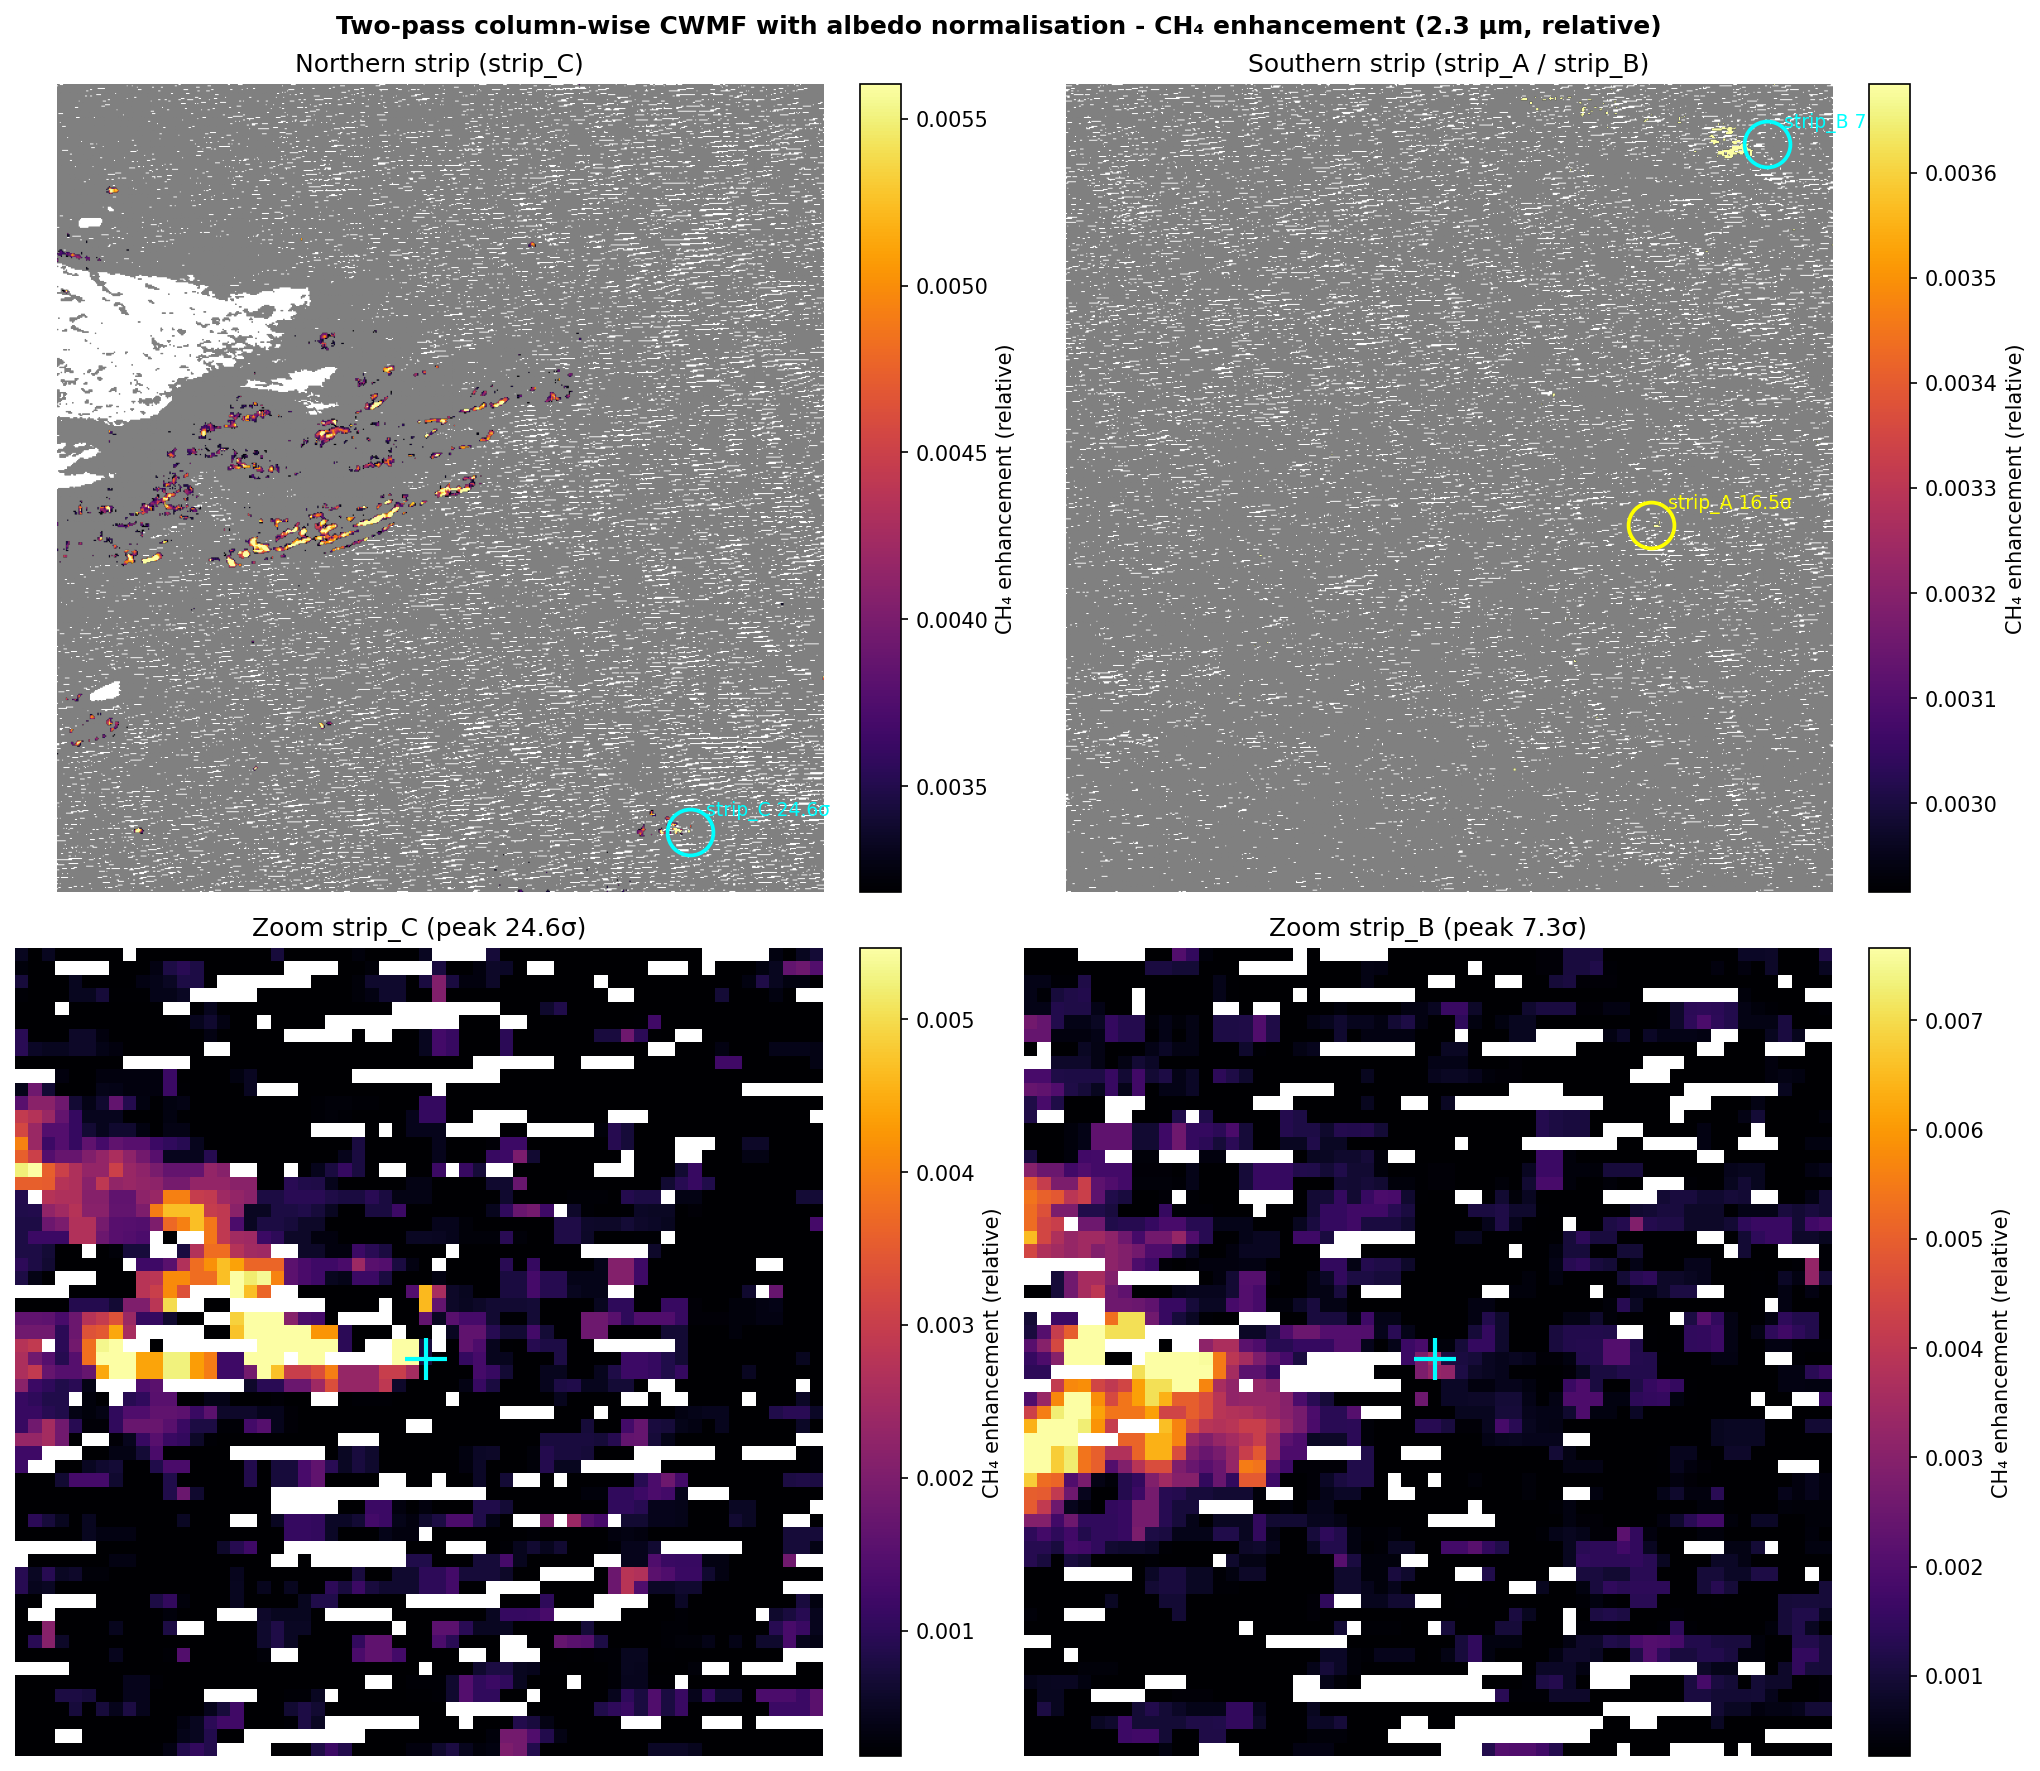

In [2]:
display(Image(filename=str(FIG_DIR / "04_cwmf_detection_map.png")))

## Signal above the local background

The histogram compares the filtered ocean background with a standard normal curve. The bars show how far each provider plume lies above the local background spread.

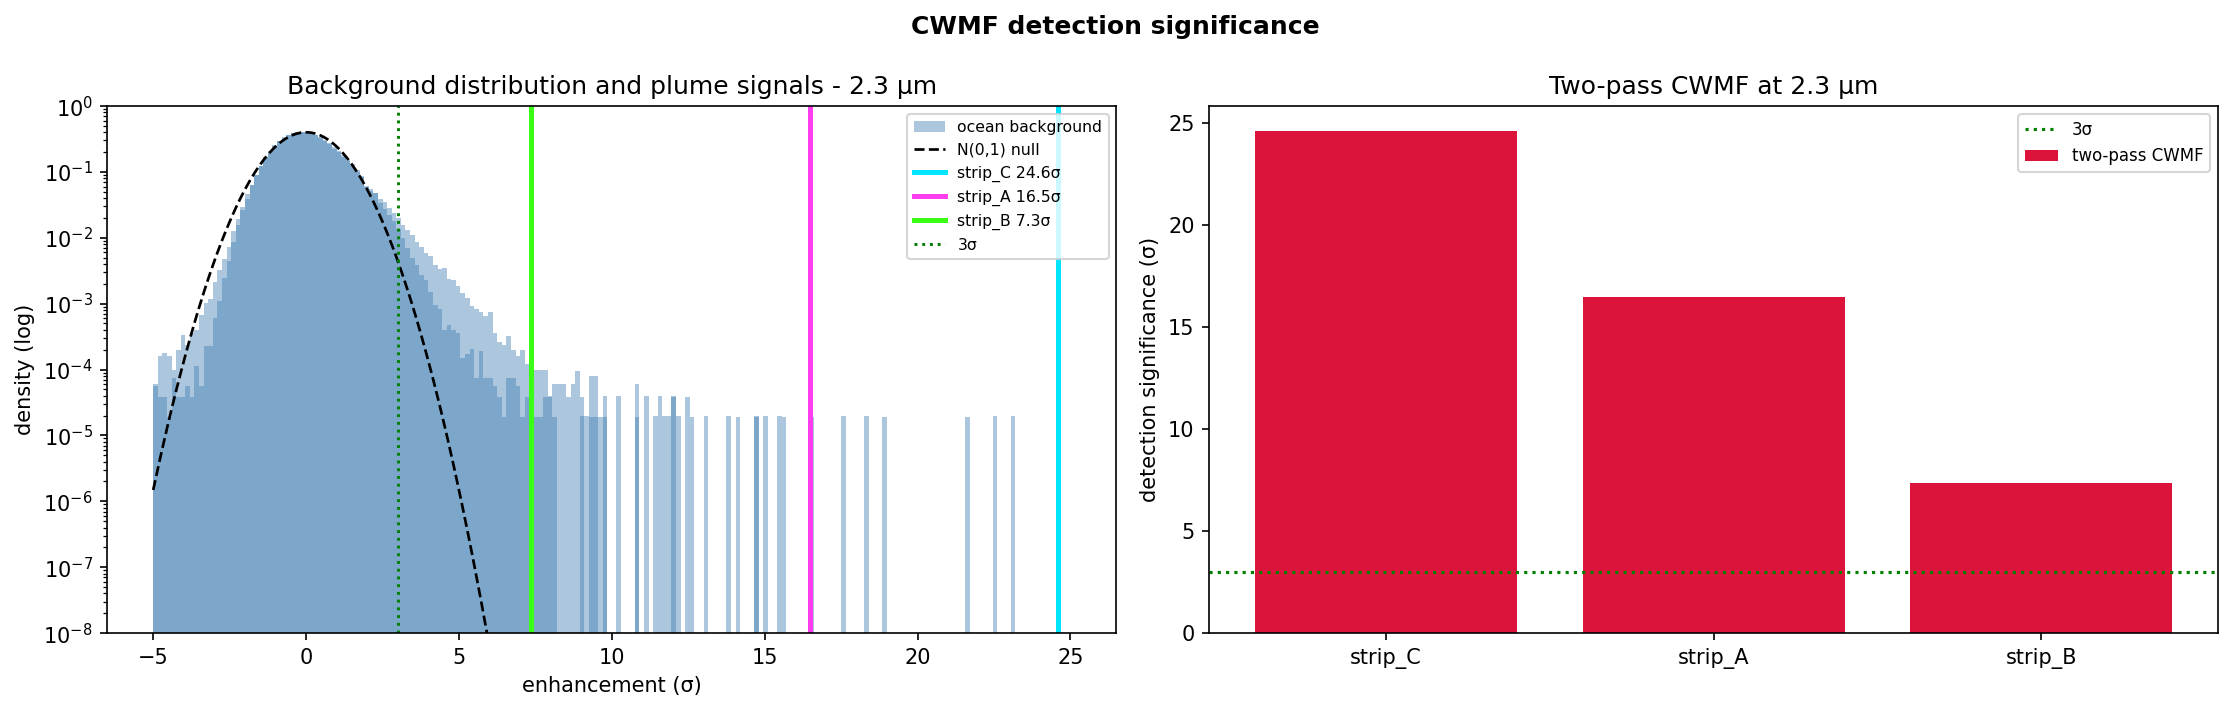

In [3]:
display(Image(filename=str(FIG_DIR / "04_cwmf_significance.png")))

## Compare with Planet's quicklook

The independent retrieval and Planet product are cropped to the same plume areas. Agreement in plume position is the main check; the two maps do not use the same retrieval method or units.

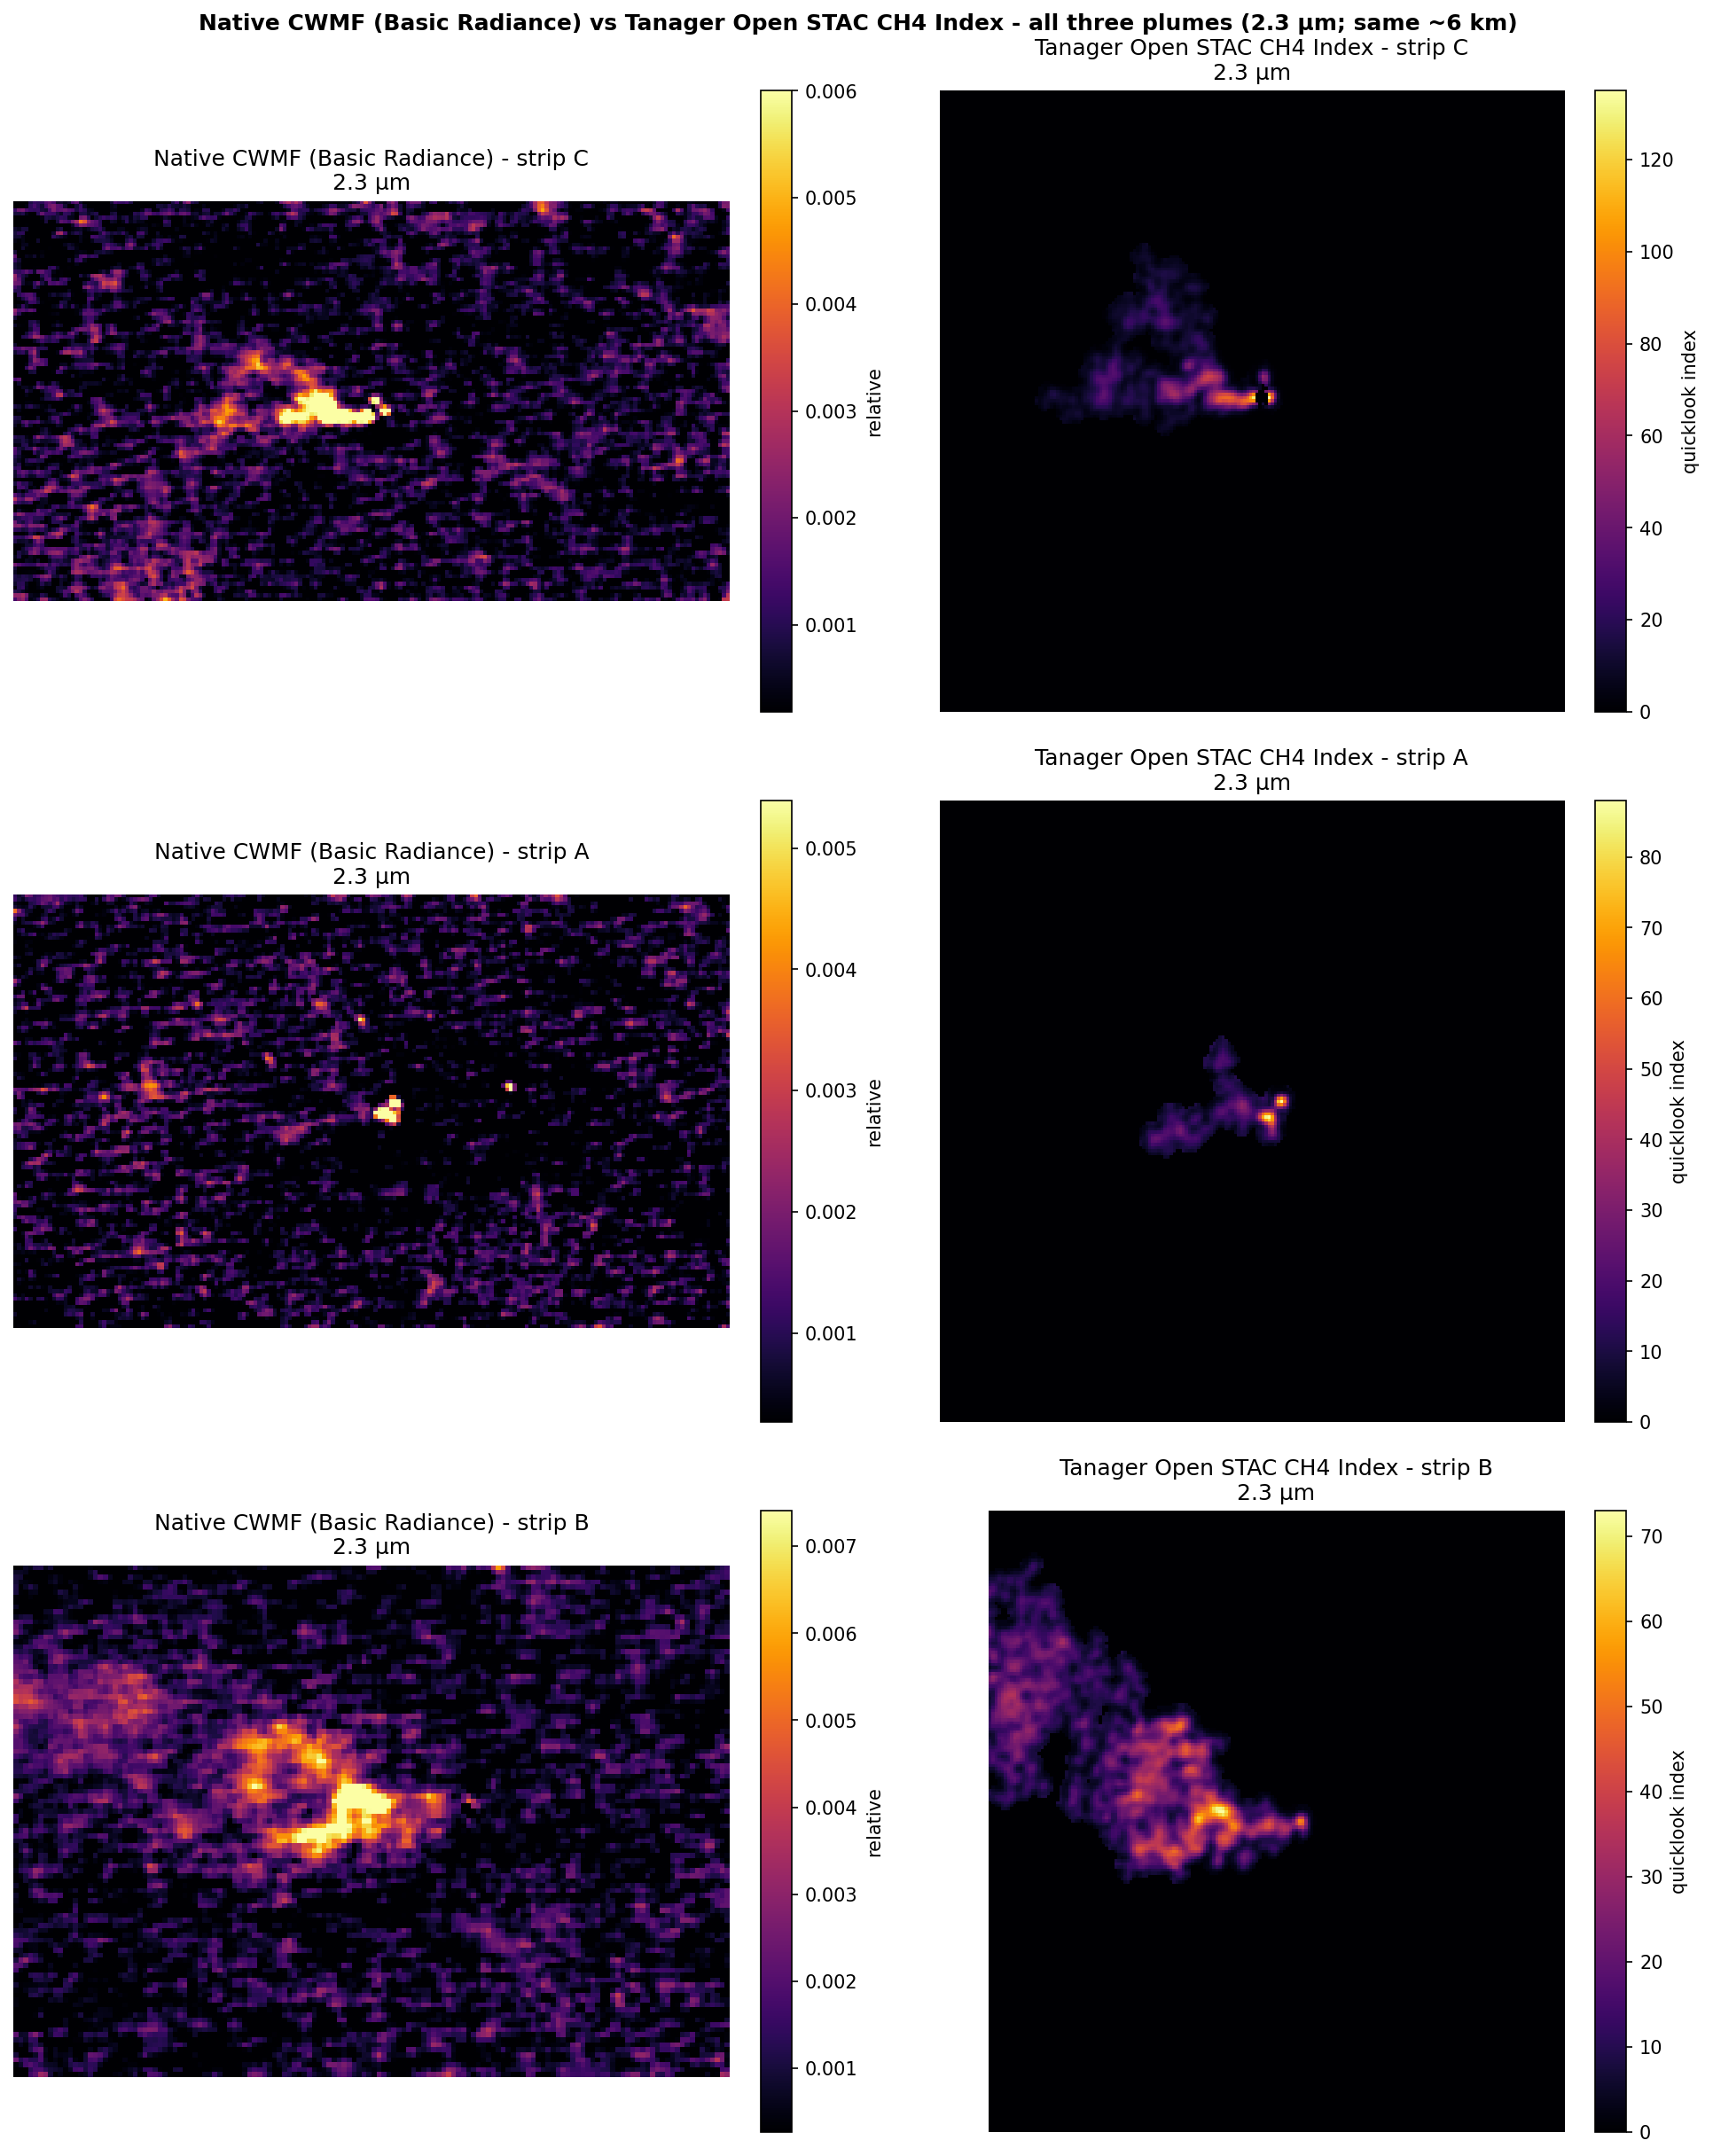

In [4]:
display(Image(filename=str(FIG_DIR / "04_cwmf_vs_planet.png")))

## Cross-check at 1.65 micrometres

The weaker methane window is retained as a check on spectral consistency. These figures use the same column-wise method as the original notebook and are not presented as a second version of the 2.3 micrometre pipeline.

## Prepare the 1.65 micrometre cross-check

This section loads only the weaker methane window. The 2.3 micrometre result above comes from the v2 script and is not calculated again here.

In [ ]:
import h5py, os, time, warnings
import numpy as np, matplotlib.pyplot as plt
from pathlib import Path
import geopandas as gpd
import rasterio
from pyproj import Transformer
from scipy.ndimage import gaussian_filter, median_filter
warnings.filterwarnings('ignore')
try: import hapi; HAVE_HITRAN=True
except Exception: HAVE_HITRAN=False
TRAPZ=getattr(np,'trapezoid',getattr(np,'trapz',None))

from pathlib import Path
import sys

PACKAGE_ROOT = Path.cwd().resolve()
while not (PACKAGE_ROOT / "scripts").is_dir() and PACKAGE_ROOT.parent != PACKAGE_ROOT:
    PACKAGE_ROOT = PACKAGE_ROOT.parent
if not (PACKAGE_ROOT / "scripts").is_dir():
    raise FileNotFoundError("Run this notebook from the cloned submission folder or its notebooks folder.")

sys.path.insert(0, str(PACKAGE_ROOT / "scripts"))

FIG_DIR = PACKAGE_ROOT / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)
HITRAN_CACHE = PACKAGE_ROOT / 'data' / 'hitran_cache'
ROOT=PACKAGE_ROOT / 'data' / 'ghg'; IDS={'north':'20250423_134021_00_4001','south':'20250423_134026_31_4001'}
RAD='HDFEOS/SWATHS/HYP/Data Fields/toa_radiance'
LATD='HDFEOS/SWATHS/HYP/Geolocation Fields/Latitude'; LOND='HDFEOS/SWATHS/HYP/Geolocation Fields/Longitude'
CLOUD='HDFEOS/SWATHS/HYP/Data Fields/beta_cloud_mask'; CIRRUS='HDFEOS/SWATHS/HYP/Data Fields/beta_cirrus_mask'
NODATA='HDFEOS/SWATHS/HYP/Data Fields/nodata_pixels'; FILL=-9999.0
TIF={'north':ROOT/IDS['north']/'ortho_ql_ch4.tif','south':ROOT/IDS['south']/'ortho_ql_ch4.tif'}
NB2_SIGMA={'C':1.2,'B':2.1,'A':0.7}                      # Notebook-2 band-ratio sigma (the simple method)

BANDS=[dict(key='165',lo=1500,hi=1780, clo=1640,chi=1690, table='CH4_b165',envc=1666,envf=35,
            label='1.65 µm', sfx='_165', primary=False)]

def load_plumes(geojson, strip):
    gdf=gpd.read_file(geojson); out=[]
    for _,r in gdf.iterrows():
        g=r.geometry; lon,lat=(g.x,g.y) if g.geom_type=='Point' else (g.centroid.x,g.centroid.y)
        pid=str(r.get('plume_id','-'))
        out.append({'label':pid.split('_strip_')[-1] if '_strip_' in pid else pid,'strip':strip,
                    'quality':r.get('plume_quality','-'),'emission':float(r.get('emission',np.nan)),
                    'ime':float(r.get('ime',np.nan)),'wind':float(r.get('wind_speed_avg',np.nan)),
                    'lon':lon,'lat':lat})
    return out
PLUMES={'north':load_plumes(ROOT/IDS['north']/'ql_ch4_json.geojson','north'),
        'south':load_plumes(ROOT/IDS['south']/'ql_ch4_json.geojson','south')}

def load_basic(path, lo, hi):
    with h5py.File(path,'r') as f:
        ds=f[RAD]; wl=ds.attrs['wavelengths'][:].astype(float); fw=ds.attrs['fwhm'][:].astype(float)
        sel=np.where((wl>=lo)&(wl<=hi))[0]; arr=ds[sel.min():sel.max()+1].astype(np.float32)
        wlw,fwhm_w=wl[sel.min():sel.max()+1],fw[sel.min():sel.max()+1]
        lat=f[LATD][()].astype(float); lon=f[LOND][()].astype(float)
        cl,ci,nd=f[CLOUD][()],f[CIRRUS][()],f[NODATA][()]
    arr[arr<=FILL+1]=np.nan
    valid=(~((cl==1)|(ci==1)|(nd==1)|(cl==255)))&np.isfinite(arr[0])&(arr[0]>0)
    return arr,wlw,fwhm_w,lat,lon,valid

def methane_envelope(wl,center,fwhm):
    s=fwhm/2.3548; A=np.exp(-0.5*((wl-center)/s)**2); return A/A.max()

def hitran_k(wl,fwhm_arr,table):
    if not HAVE_HITRAN or TRAPZ is None: return None
    try:
        HITRAN_CACHE.mkdir(parents=True, exist_ok=True); hapi.db_begin(str(HITRAN_CACHE))
        nl,nh=1e7/wl.max(),1e7/wl.min()
        if table not in hapi.tableList(): hapi.fetch(table,6,1,nl-30,nh+30)
        nu,xs=hapi.absorptionCoefficient_Voigt(SourceTables=table,HITRAN_units=True,
              Environment={'p':1.0,'T':290.0},WavenumberStep=0.01)
        lam=1e7/nu; o=np.argsort(lam); lam,xs=lam[o],xs[o]; k=np.empty(len(wl))
        for i,(w,fwh) in enumerate(zip(wl,fwhm_arr)):
            s=fwh/2.3548; m=np.abs(lam-w)<5*fwh; g=np.exp(-0.5*((lam[m]-w)/s)**2)
            k[i]=TRAPZ(xs[m]*g,lam[m])/TRAPZ(g,lam[m])
        return k*2.46e15
    except Exception as e:
        print('  HITRAN failed',repr(e)); return None

def cwmf_detector(arr,valid,k_vec,SHO,ridge=1e-3):
    B,Sc,D=arr.shape; alpha=np.full((Sc,D),np.nan,np.float32); ndet=0
    for d in range(D):
        good=valid[:,d]
        if int(good.sum())<max(3*B,60): continue
        Xc=arr[:,good,d].T; bk=Xc[:,SHO].mean(1); bmed=np.median(bk); bmad=np.median(np.abs(bk-bmed))*1.4826+1e-9
        keep=np.abs(bk-bmed)<3*bmad; Xb=Xc[keep] if int(keep.sum())>max(3*B,60) else Xc
        mu=Xb.mean(0); C=np.cov(Xb,rowvar=False); C.flat[::B+1]+=ridge*np.trace(C)/B
        try: Cinv=np.linalg.inv(C)
        except: continue
        t=mu*k_vec; Ct=Cinv@t; den=float(t@Ct)
        if den<=0: continue
        alpha[:,d]=(-(((arr[:,:,d].T-mu)@Ct)/den)).astype(np.float32); ndet+=1
    return alpha,ndet

def nearest(lat,lon,plat,plon):
    return tuple(int(v) for v in np.unravel_index(np.nanargmin((lat-plat)**2+(lon-plon)**2),lat.shape))
def robust_stats(a):
    o=a[np.isfinite(a)]; m=np.median(o); s=np.median(np.abs(o-m))*1.4826+1e-12; return m,s

def process_band(b):
    '''Load both strips, build HITRAN target, run CWMF -> results for this band.'''
    out={'label':b['label'],'sfx':b['sfx']}
    # build target on north grid
    a0,wlw,fwhm_w,_,_,_=load_basic(ROOT/IDS['north']/'basic_radiance_hdf5.h5',b['lo'],b['hi']); del a0
    SHO=~((wlw>=b['clo'])&(wlw<=b['chi']))
    k=hitran_k(wlw,fwhm_w,b['table']); out['UNIT']='ppm·m' if k is not None else 'relative'
    if k is None: k=methane_envelope(wlw,b['envc'],b['envf'])
    out['k']=k; out['wlw']=wlw; out['SHO']=SHO; out['have_ppmm']=(out['UNIT']=='ppm·m')
    strips={}
    for s in ('north','south'):
        arr,_,_,lat,lon,valid=load_basic(ROOT/IDS[s]/'basic_radiance_hdf5.h5',b['lo'],b['hi'])
        if s=='north': out['mu0']=np.nanmean(arr[:,valid],axis=1)
        alpha,ndet=cwmf_detector(arr,valid,k,SHO); alpha[~valid]=np.nan
        m0,s0=robust_stats(alpha); alpha[np.abs((alpha-m0)/s0)>25]=np.nan
        med,sig=robust_stats(alpha); pts=[]
        for p in PLUMES[s]:
            r,c=nearest(lat,lon,p['lat'],p['lon']); pk=float(np.nanmax(alpha[max(0,r-5):r+6,max(0,c-5):c+6]))
            pts.append({**p,'row':r,'col':c,'peak':pk,'sigma':(pk-med)/sig})
        strips[s]=dict(alpha=alpha,med=med,sig=sig,pts=pts,lat=lat,lon=lon,valid=valid,ndet=ndet)
        del arr
    out['strips']=strips; return out

print('Processing both bands (2.3 um primary, 1.65 um secondary)...')
RESULTS={}
for b in BANDS:
    t0=time.time(); RESULTS[b['key']]=process_band(b)
    R=RESULTS[b['key']]
    msg=" ".join(f"strip_{p['label']}:{p['sigma']:.1f}σ" for s in ('north','south') for p in R['strips'][s]['pts'])
    print(f"  {b['label']:7} ({R['UNIT']}): {msg}  [{time.time()-t0:.0f}s]")


## Figure helpers

In [6]:
def crop_slices(r,c,shape,half=30):
    return (slice(max(0,r-half),min(shape[0],r+half)),slice(max(0,c-half),min(shape[1],c+half)))

def fig_target(R,label,sfx):
    k=R['k']/R['k'].max(); wlw=R['wlw']; mu0=R['mu0']
    fig,(a1,a2)=plt.subplots(1,2,figsize=(14,4.2))
    a1.plot(wlw,k,color='crimson',lw=2); a1.set_title(f'CH₄ absorption k(λ) - {label}'); a1.set_xlabel('nm')
    a1.set_ylabel('relative absorption')
    a2.plot(wlw,mu0,color='steelblue',lw=1.3); a2b=a2.twinx(); a2b.plot(wlw,mu0*k,color='crimson',lw=2)
    a2.set_title(f'target t=μ·k - {label}'); a2.set_xlabel('nm'); a2.set_ylabel('μ radiance',color='steelblue')
    a2b.set_ylabel('target',color='crimson')
    plt.suptitle(f'Matched-filter methane target ({label}, {R["UNIT"]})',fontweight='bold'); plt.tight_layout()
    plt.savefig(FIG_DIR/f'04_cwmf_target{sfx}.png',dpi=150,bbox_inches='tight'); plt.show(); print('Saved 04_cwmf_target'+sfx+'.png')

def display_map(S):
    a=np.where(np.isfinite(S['alpha']),S['alpha'],S['med']); d=median_filter(a,size=3)
    d[~np.isfinite(S['alpha'])]=np.nan; return d

def fig_detection(R,label,sfx):
    U=R['UNIT']
    fig,axes=plt.subplots(2,2,figsize=(14,12))
    for ax,s,title in [(axes[0,0],'north','Northern strip (strip_C)'),(axes[0,1],'south','Southern strip (strip_A / strip_B)')]:
        S=R['strips'][s]; d=display_map(S); thr=S['med']+2*S['sig']; hi=np.nanpercentile(d,99.8)
        ax.imshow(np.where(np.isfinite(d),0.,np.nan),cmap='gray',vmin=-1,vmax=1)
        im=ax.imshow(np.where(d>thr,d,np.nan),cmap='inferno',vmin=thr,vmax=hi)
        plt.colorbar(im,ax=ax,fraction=.046,pad=.04,label=f'CH₄ enhancement ({U})')
        for q in S['pts']:
            ec='cyan' if q['quality']=='good' else 'yellow'
            ax.plot(q['col'],q['row'],'o',mfc='none',mec=ec,ms=22,mew=1.8)
            ax.annotate(f"strip_{q['label']} {q['sigma']:.1f}σ",(q['col'],q['row']),color=ec,fontsize=9,
                        xytext=(8,8),textcoords='offset points')
        ax.set_title(title); ax.axis('off')
    for ax,(s,lbl) in zip([axes[1,0],axes[1,1]],[('north','C'),('south','B')]):
        S=R['strips'][s]; d=display_map(S); q=next(x for x in S['pts'] if x['label']==lbl)
        rs,cs=crop_slices(q['row'],q['col'],d.shape,30); sub=d[rs,cs]
        im=ax.imshow(sub,cmap='inferno',vmin=S['med'],vmax=max(S['med']+3*S['sig'],np.nanpercentile(sub,99)))
        plt.colorbar(im,ax=ax,fraction=.046,pad=.04,label=f'CH₄ enhancement ({U})')
        ax.plot(q['col']-cs.start,q['row']-rs.start,'+',color='cyan',ms=20,mew=2)
        ax.set_title(f"Zoom strip_{lbl} (peak {q['sigma']:.1f}σ)"); ax.axis('off')
    plt.suptitle(f'Per-detector CWMF - CH₄ enhancement ({label}, {U})',fontweight='bold'); plt.tight_layout()
    plt.savefig(FIG_DIR/f'04_cwmf_detection_map{sfx}.png',dpi=150,bbox_inches='tight'); plt.show()
    print('Saved 04_cwmf_detection_map'+sfx+'.png')

PLUME_COL={'C':'#00e5ff','A':'#ff3df0','B':'#39ff14'}    # bright, distinct from the grey ocean histogram
def fig_significance(R,label,sfx):
    fig,(axh,axb)=plt.subplots(1,2,figsize=(15,4.8))
    for s in ('north','south'):
        S=R['strips'][s]; z=(S['alpha']-S['med'])/S['sig']
        axh.hist(z[np.isfinite(z)],bins=200,range=(-5,22),density=True,color='0.6',alpha=.45,
                 label=f'{s} ocean' if s=='north' else None)
    xx=np.linspace(-5,22,400); axh.plot(xx,np.exp(-xx**2/2)/np.sqrt(2*np.pi),'k--',lw=1.3,label='N(0,1) null')
    for s in ('north','south'):
        for q in R['strips'][s]['pts']:
            axh.axvline(q['sigma'],color=PLUME_COL.get(q['label'],'red'),lw=2.4,
                        label=f"strip_{q['label']} {q['sigma']:.1f}σ")
    axh.axvline(3,color='green',ls=':',lw=1.4,label='3σ'); axh.set_yscale('log')
    axh.set_xlabel('enhancement (σ)'); axh.set_ylabel('density (log)')
    axh.set_title(f'Background ~Gaussian; plumes in the tail - {label}'); axh.legend(fontsize=7.5)
    labels=[f"strip_{q['label']}" for s in ('north','south') for q in R['strips'][s]['pts']]
    mf_s=[q['sigma'] for s in ('north','south') for q in R['strips'][s]['pts']]
    br_s=[NB2_SIGMA[q['label']] for s in ('north','south') for q in R['strips'][s]['pts']]
    xp=np.arange(len(labels)); w=0.38
    axb.bar(xp-w/2,br_s,w,color='steelblue',label='Notebook-2 band ratio')
    axb.bar(xp+w/2,mf_s,w,color='crimson',label='Per-detector CWMF')
    axb.axhline(3,color='green',ls=':',label='3σ'); axb.set_xticks(xp); axb.set_xticklabels(labels)
    axb.set_ylabel('detection significance (σ)'); axb.set_title(f'CWMF vs band ratio - {label}'); axb.legend(fontsize=8)
    plt.suptitle(f'Detection significance ({label})',fontweight='bold'); plt.tight_layout()
    plt.savefig(FIG_DIR/f'04_cwmf_significance{sfx}.png',dpi=150,bbox_inches='tight'); plt.show()
    print('Saved 04_cwmf_significance'+sfx+'.png')

HK=3.0
def _hw(plat,hk=HK): return hk/111.0, hk/(111.0*np.cos(np.radians(plat)))
def crop_cube_geo(field,lat,lon,plat,plon,hk=HK):
    dlat,dlon=_hw(plat,hk); m=(np.abs(lat-plat)<dlat)&(np.abs(lon-plon)<dlon)
    rr,cc=np.where(m.any(1))[0],np.where(m.any(0))[0]
    return field[rr.min():rr.max()+1,cc.min():cc.max()+1] if rr.size and cc.size else field
def crop_planet_geo(tif,plat,plon,hk=HK):
    dlat,dlon=_hw(plat,hk)
    with rasterio.open(tif) as src:
        tr=Transformer.from_crs('EPSG:4326',src.crs,always_xy=True); rs,cs=[],[]
        for lo,la in [(plon-dlon,plat-dlat),(plon+dlon,plat+dlat),(plon-dlon,plat+dlat),(plon+dlon,plat-dlat)]:
            x,y=tr.transform(lo,la); r,c=src.index(x,y); rs.append(r); cs.append(c)
        band=src.read(1).astype(float)
    return band[max(0,min(rs)):max(rs),max(0,min(cs)):max(cs)]
def fill_disp(z,s=1.2):
    m=np.isfinite(z).astype(np.float32); zf=np.nan_to_num(z)
    out=gaussian_filter(zf*m,s)/np.maximum(gaussian_filter(m,s),1e-6); return gaussian_filter(np.where(np.isfinite(z),z,out),0.7)

def fig_vs_planet(R,label,sfx):
    U=R['UNIT']
    panels=[('north','C'),('south','A'),('south','B')]
    fig,axes=plt.subplots(3,2,figsize=(13,16.5))
    for i,(s,lbl) in enumerate(panels):
        S=R['strips'][s]; q=next(x for x in S['pts'] if x['label']==lbl)
        ours=fill_disp(crop_cube_geo(S['alpha'],S['lat'],S['lon'],q['lat'],q['lon']))
        planet=crop_planet_geo(TIF[s],q['lat'],q['lon'])
        im0=axes[i,0].imshow(ours,cmap='inferno',vmin=S['med'],
                             vmax=max(S['med']+3*S['sig'],np.nanpercentile(ours,99.5)))
        axes[i,0].set_title(f"Our CWMF ({U}) - strip_{lbl} ({q['sigma']:.1f}σ, {q['quality']})\n{label}, ~6 km")
        plt.colorbar(im0,ax=axes[i,0],fraction=.046,pad=.04,label=U)
        im1=axes[i,1].imshow(planet,cmap='inferno'); axes[i,1].set_title(f"Planet/Carbon Mapper CH₄ - strip_{lbl}\northo, same ~6 km")
        plt.colorbar(im1,ax=axes[i,1],fraction=.046,pad=.04,label='quicklook index')
        for a in (axes[i,0],axes[i,1]): a.axis('off')
    plt.suptitle(f'CWMF vs Planet - all three plumes ({label}; both ~6 km)',fontweight='bold'); plt.tight_layout()
    plt.savefig(FIG_DIR/f'04_cwmf_vs_planet{sfx}.png',dpi=150,bbox_inches='tight'); plt.show()
    print('Saved 04_cwmf_vs_planet'+sfx+'.png')

def do_flux(R,label):
    if not R['have_ppmm']: print(f'{label}: no ppm-m -> flux skipped'); return
    OMEGA=6.7e-7; APIX=32.0**2
    print(f'Independent CWMF flux - {label} (blind; vs Planet):')
    for s in ('north','south'):
        S=R['strips'][s]
        for q in S['pts']:
            r,c=q['row'],q['col']; box=S['alpha'][max(0,r-8):r+9,max(0,c-8):c+9]
            enh=box[box>S['med']+3*S['sig']]-S['med']; ime=float(np.nansum(enh)*OMEGA*APIX)
            U,L=q['wind'],np.sqrt(max(enh.size,1)*APIX); Q=ime*U/max(L,1.)*3600.
            print(f"  strip_{q['label']}: IME={ime:6.1f} kg, Q={Q:7.0f} kg/hr (Planet IME={q['ime']:.0f}, Q={q['emission']:.0f})")
print('Figure helpers ready.')


Figure helpers ready.


# Cross-check: 1.65 micrometres

## Methane target

In [7]:
fig_target(RESULTS['165'],'1.65 µm','_165')


Saved 04_cwmf_target_165.png


## Detection map

In [8]:
fig_detection(RESULTS['165'],'1.65 µm','_165')


Saved 04_cwmf_detection_map_165.png


## Signal above the local background

In [9]:
fig_significance(RESULTS['165'],'1.65 µm','_165')


Saved 04_cwmf_significance_165.png


## Compare with Planet's methane quicklook

In [10]:
fig_vs_planet(RESULTS['165'],'1.65 µm','_165')


Saved 04_cwmf_vs_planet_165.png


## Emission-rate check

In [11]:
do_flux(RESULTS['165'],'1.65 µm')


1.65 µm: no ppm-m -> flux skipped


## Result and limits

The v2 2.3 micrometre retrieval places the plume cores in the same locations as Planet's quicklook. The 1.65 micrometre window gives a weaker but useful cross-check. Provider emission rates remain the quantitative reference because the independent rate estimate is sensitive to wind, plume boundaries, and the assumed transport model.